# Feature selection, PCA and pipelines

Second half of the MLP preprocessing colab:

1. Composite transformers (`ColumnTransformer`, `TransformedTargetRegressor`)
2. Feature selection (filter and wrapper methods)
3. PCA
4. Pipelines (`Pipeline`, `FeatureUnion`, grid search over a pipeline, caching)

Most examples use the diabetes dataset since it's bundled with sklearn and has readable feature names.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X_diab, y_diab = load_diabetes(return_X_y=True, as_frame=True)
X_diab.shape

(442, 10)

## 1. Composite transformers

### ColumnTransformer

Real datasets have numeric and categorical columns that need different treatment. `ColumnTransformer`
applies a different transformer to each group of columns and glues the results back together side by side.

Each entry is `(name, transformer, columns)`. The transformer can also be `'passthrough'` (keep as is) or
`'drop'`.

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MaxAbsScaler

kids = pd.DataFrame({'age':    [20.0, 11.2, 15.6, 13.0, 18.6, 16.4],
                     'gender': ['male', 'female', 'female', 'male', 'male', 'female']})

ct = ColumnTransformer([
    ('scaled', MaxAbsScaler(), ['age']),
    ('raw', 'passthrough', ['age']),
    ('onehot', OneHotEncoder(), ['gender']),
])
pd.DataFrame(ct.fit_transform(kids), columns=ct.get_feature_names_out())

,scaled__age,raw__age,onehot__gender_female,onehot__gender_male
0,1.00,20.0,0.0,1.0
1,0.56,11.2,1.0,0.0
2,0.78,15.6,1.0,0.0
3,0.65,13.0,0.0,1.0
4,0.93,18.6,0.0,1.0
5,0.82,16.4,1.0,0.0


In the original colab the input was a NumPy array, and since NumPy arrays hold one type the whole output
came back as strings (`'1.0'`, `'20.0'`). Using a DataFrame avoids that, and lets you pick columns by name.

`remainder` controls what happens to columns that aren't listed (default `'drop'`).

### TransformedTargetRegressor

Transforms `y` before fitting, and automatically applies the inverse to the predictions. The usual case is
a skewed target where predicting `log(y)` is easier.

A heavily skewed synthetic target:

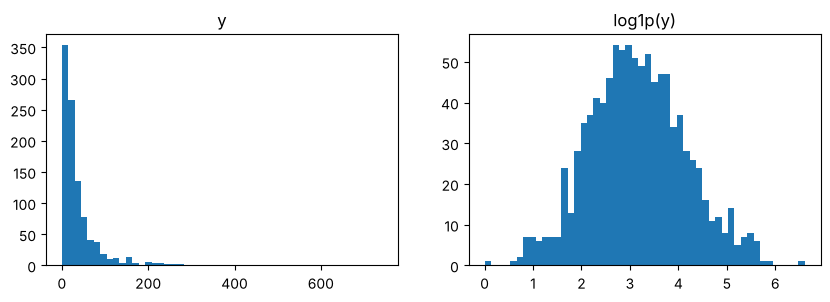

In [3]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=1000, n_features=5, noise=5, random_state=0)
y = np.expm1((y + abs(y.min())) / 100)        # exponentiate -> long right tail

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(y, bins=50); axes[0].set_title('y')
axes[1].hist(np.log1p(y), bins=50); axes[1].set_title('log1p(y)')
plt.show()

In [4]:
plain = LinearRegression().fit(X_train, y_train)

with_log = TransformedTargetRegressor(regressor=LinearRegression(),
                                      func=np.log1p, inverse_func=np.expm1).fit(X_train, y_train)

print(f"R2, raw target:        {plain.score(X_test, y_test):.3f}")
print(f"R2, log-transformed y: {with_log.score(X_test, y_test):.3f}")

R2, raw target:        0.680
R2, log-transformed y: 0.997


`score` and `predict` work on the original scale of `y`, the log/exp happens inside.

The course colab used `MaxAbsScaler` as the target transformer and got the same R2 (0.59) both times.
That's expected: a linear model fitted on `y / c` just has all its coefficients divided by `c`, so the
predictions after undoing the scaling are identical. The transform has to be non-linear to make a difference.

---

## 2. Feature selection

Fewer features means faster training, less overfitting and an easier model to explain.

* **filter methods** score each feature on its own (variance, correlation with `y`, mutual information)
  and keep the best. Fast, but ignore interactions between features.
* **wrapper methods** train a model on different subsets and keep whatever subset works best. Slower,
  but take the model into account.

### VarianceThreshold

Drops features whose variance is below a threshold. The default (0) only removes constant columns.

In [5]:
from sklearn.feature_selection import VarianceThreshold

children = pd.DataFrame({'age': [4, 1, 3, 2], 'height': [96.0, 73.9, 88.9, 81.6]})
children.var(ddof=0)

age        1.250
height    67.735
dtype: float64

In [6]:
vt = VarianceThreshold(threshold=9)
vt.fit_transform(children), vt.get_feature_names_out()

(array([[96. ],
        [73.9],
        [88.9],
        [81.6]]),
 array(['height'], dtype=object))

`age` has variance 1.25 < 9, so only `height` is kept. Variance depends on units, so this is mostly useful
for removing constant or near-constant columns, not for ranking features in general.

### SelectKBest

Scores every feature against the target and keeps the top `k`. The scoring function depends on the problem:

* regression: `f_regression` (linear correlation), `mutual_info_regression` (any dependency)
* classification: `f_classif`, `mutual_info_classif`, `chi2`

In [7]:
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression

skb = SelectKBest(f_regression, k=3).fit(X_diab, y_diab)
skb.get_feature_names_out()

array(['bmi', 'bp', 's5'], dtype=object)

In [8]:
pd.Series(skb.scores_, index=X_diab.columns).sort_values(ascending=False).round(1)

bmi    230.7
s5     207.3
bp     106.5
s4     100.1
s3      81.2
s6      75.4
s1      20.7
age     16.1
s2      13.7
sex      0.8
dtype: float64

In [9]:
mi = mutual_info_regression(X_diab, y_diab, random_state=0)
pd.Series(mi, index=X_diab.columns).sort_values(ascending=False).round(3)

bmi    0.171
s5     0.144
s4     0.113
s6     0.106
bp     0.066
s3     0.065
s1     0.063
s2     0.015
sex    0.014
age    0.001
dtype: float64

Both put `bmi` and `s5` at the top, which matches the correlations in the pandas notebook.

### SelectPercentile and GenericUnivariateSelect

`SelectPercentile` keeps the top x% instead of a fixed count. `GenericUnivariateSelect` covers all of
these with a `mode` parameter (`'k_best'`, `'percentile'`, `'fpr'`, `'fdr'`, `'fwe'`).

In [10]:
from sklearn.feature_selection import SelectPercentile, GenericUnivariateSelect

sp = SelectPercentile(f_regression, percentile=30).fit(X_diab, y_diab)
sp.get_feature_names_out()          # 30% of 10 features = 3

array(['bmi', 'bp', 's5'], dtype=object)

In [11]:
gus = GenericUnivariateSelect(f_regression, mode='k_best', param=3).fit(X_diab, y_diab)
gus.get_feature_names_out()

array(['bmi', 'bp', 's5'], dtype=object)

### RFE (recursive feature elimination)

1. fit the model on all current features
2. rank them by importance (`coef_` or `feature_importances_`) and drop the weakest `step` of them
3. repeat until `n_features_to_select` are left

Coefficients are only comparable when the features are on the same scale. The diabetes features already
are (sklearn scales them by default).

In [12]:
from sklearn.feature_selection import RFE

rfe = RFE(LinearRegression(), n_features_to_select=3, step=1).fit(X_diab, y_diab)

pd.DataFrame({'selected': rfe.support_, 'rank': rfe.ranking_}, index=X_diab.columns).sort_values('rank')

,selected,rank
bmi,True,1
s1,True,1
s5,True,1
s2,False,2
bp,False,3
sex,False,4
s4,False,5
s3,False,6
s6,False,7
age,False,8


Rank 1 means selected, higher ranks were eliminated earlier.

### RFECV

Same, but picks the number of features itself using cross validation.

In [13]:
from sklearn.feature_selection import RFECV

rfecv = RFECV(LinearRegression(), step=1, cv=5, scoring='r2').fit(X_diab, y_diab)
print("best number of features:", rfecv.n_features_)
print("selected:", list(rfecv.get_feature_names_out()))

best number of features: 6
selected: ['sex', 'bmi', 'bp', 's1', 's2', 's5']


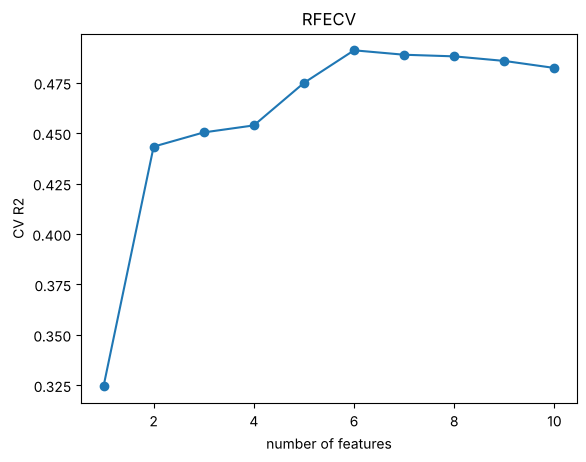

In [14]:
scores = rfecv.cv_results_['mean_test_score']
plt.plot(range(1, len(scores) + 1), scores, marker='o')
plt.xlabel('number of features'); plt.ylabel('CV R2')
plt.title('RFECV')
plt.show()

### SelectFromModel

Fits the model once and keeps features whose importance is above a threshold (a number, or a string like
`'mean'`, `'median'`, `'1.5*mean'`). `max_features` caps how many are kept.

In [15]:
from sklearn.feature_selection import SelectFromModel

lr = LinearRegression().fit(X_diab, y_diab)
pd.Series(lr.coef_, index=X_diab.columns).abs().sort_values(ascending=False).round(1)

s1     792.2
s5     751.3
bmi    519.8
s2     476.7
bp     324.4
sex    239.8
s4     177.1
s3     101.0
s6      67.6
age     10.0
dtype: float64

In [16]:
sfm = SelectFromModel(LinearRegression(), max_features=3, threshold=-np.inf).fit(X_diab, y_diab)
sfm.get_feature_names_out()

array(['bmi', 's1', 's5'], dtype=object)

`threshold=-np.inf` means "ignore the threshold and just take the top `max_features`". Importance here
is the absolute value of the coefficient.

`s1` comes out on top even though on its own it barely relates to the target (its f-score above was only
20.7). `s1` and `s2` are strongly correlated (r = 0.90), and the model gives them big coefficients with opposite
signs (-792 and +477) that mostly cancel out. So a large coefficient doesn't always mean an important feature.
The univariate methods picked `bp` instead of `s1`.

### SequentialFeatureSelector

Greedy search using cross-validated score. **Forward** starts with nothing and adds the feature that helps
most each round. **Backward** starts with everything and removes the one that hurts least.

In [17]:
%%time
from sklearn.feature_selection import SequentialFeatureSelector

sfs_fwd = SequentialFeatureSelector(LinearRegression(), n_features_to_select=3,
                                    direction='forward').fit(X_diab, y_diab)
sfs_fwd.get_feature_names_out()

CPU times: user 315 ms, sys: 94 μs, total: 315 ms
Wall time: 322 ms


array(['bmi', 'bp', 's5'], dtype=object)

In [18]:
%%time
sfs_bwd = SequentialFeatureSelector(LinearRegression(), n_features_to_select=3,
                                    direction='backward').fit(X_diab, y_diab)
sfs_bwd.get_feature_names_out()

CPU times: user 568 ms, sys: 0 ns, total: 568 ms
Wall time: 570 ms


array(['bmi', 'bp', 's5'], dtype=object)

Forward needs fewer model fits when you want a small subset, backward when you want to drop only a few.
The two don't always agree because each greedy step depends on what was picked before.

---

## 3. PCA

Principal component analysis finds new axes (directions) in the data, ordered by how much of the variance
they capture. Each axis is a combination of the original features and they're all perpendicular to each other.
Keeping only the first few gives a lower-dimensional version of the data that loses as little as possible.

2D example so it can be drawn:

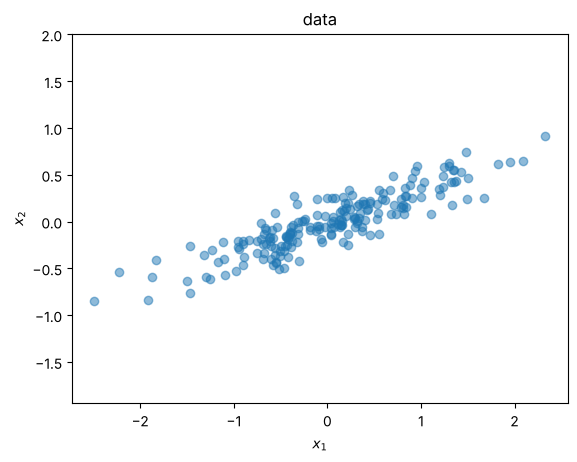

In [19]:
rng = np.random.RandomState(1)
X = (rng.rand(2, 2) @ rng.randn(2, 200)).T

plt.scatter(X[:, 0], X[:, 1], alpha=0.5)
plt.axis('equal')
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.title('data')
plt.show()

In [20]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2).fit(X)

print("components (one per row):\n", pca.components_)
print("explained variance:", pca.explained_variance_)
print("explained variance ratio:", pca.explained_variance_ratio_)
print("mean:", pca.mean_)

components (one per row):
 [[ 0.94446029  0.32862557]
 [-0.32862557  0.94446029]]
explained variance: [0.7625315 0.0184779]
explained variance ratio: [0.97634101 0.02365899]
mean: [ 0.03351168 -0.00408072]


Each **row** of `components_` is one principal axis (a unit vector). The first one explains about 98% of
the variance.

Drawing the axes from the mean, with length = sqrt(variance) i.e. one standard deviation along that axis.
`C3` is an arbitrary direction for comparison.

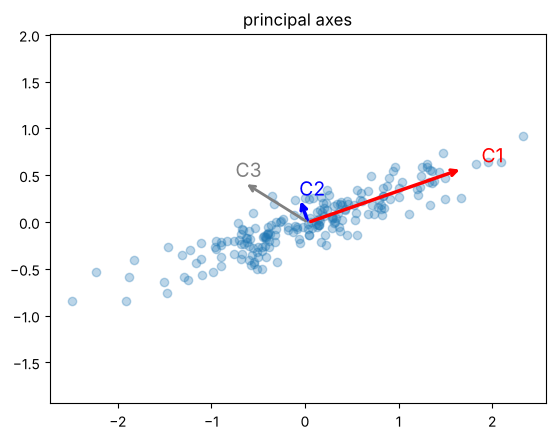

In [21]:
c3 = np.array([-0.85, 0.53])     # some other unit vector

plt.scatter(X[:, 0], X[:, 1], alpha=0.3)
for vec, var, name, colour in zip(pca.components_, pca.explained_variance_, ['C1', 'C2'], ['r', 'b']):
    end = pca.mean_ + vec * 2 * np.sqrt(var)
    plt.annotate('', xy=end, xytext=pca.mean_, arrowprops=dict(arrowstyle='->', color=colour, lw=2.5))
    plt.text(*(end * 1.12), name, color=colour, fontsize=14)

end = pca.mean_ + c3 * 0.8
plt.annotate('', xy=end, xytext=pca.mean_, arrowprops=dict(arrowstyle='->', color='grey', lw=2))
plt.text(*(end * 1.15), 'C3', color='grey', fontsize=14)

plt.axis('equal')
plt.title('principal axes')
plt.show()

Projecting all points onto each direction shows how much spread each one keeps:

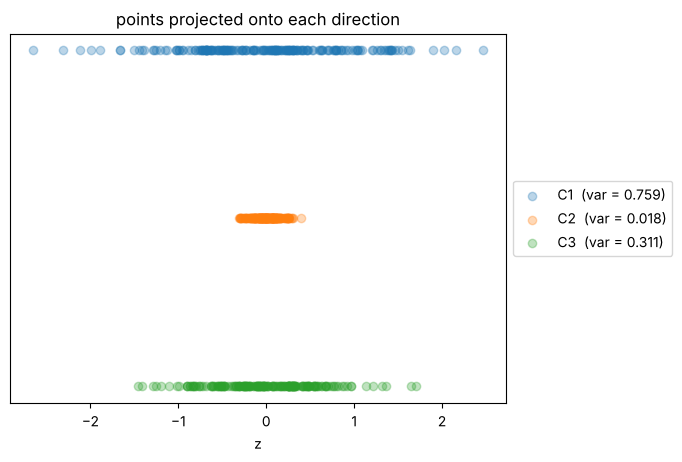

In [22]:
Xc = X - pca.mean_
proj = {'C1': Xc @ pca.components_[0], 'C2': Xc @ pca.components_[1], 'C3': Xc @ c3}

for i, (name, z) in enumerate(proj.items()):
    plt.scatter(z, np.full_like(z, -i), alpha=0.3, label=f"{name}  (var = {z.var():.3f})")
plt.yticks([]); plt.xlabel('z')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('points projected onto each direction')
plt.show()

C1 keeps the most spread, as it should, since it's the direction of maximum variance. C2 keeps almost none.
Any other direction like C3 is somewhere in between.

### Reducing dimensions

Keep only the first component, then map back to 2D with `inverse_transform` to see what was kept.

original: (200, 2)  reduced: (200, 1)


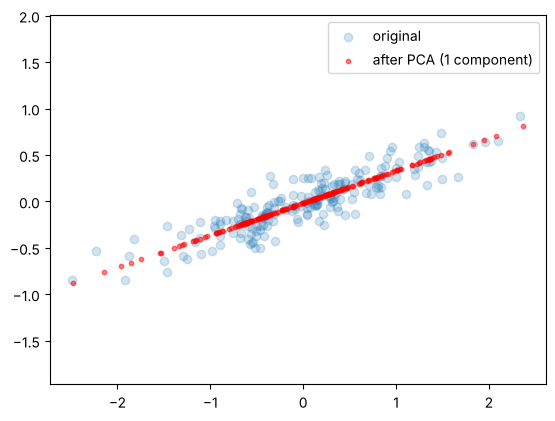

In [23]:
pca1 = PCA(n_components=1).fit(X)
X_1d = pca1.transform(X)
X_back = pca1.inverse_transform(X_1d)

print("original:", X.shape, " reduced:", X_1d.shape)

plt.scatter(X[:, 0], X[:, 1], alpha=0.2, label='original')
plt.scatter(X_back[:, 0], X_back[:, 1], alpha=0.5, c='r', s=10, label='after PCA (1 component)')
plt.axis('equal'); plt.legend()
plt.show()

Every point got projected onto the C1 line. The information along C2 is gone, but that was only ~2% of
the variance.

### How many components?

On a real dataset, look at the cumulative explained variance. Digits has 64 features (pixels):

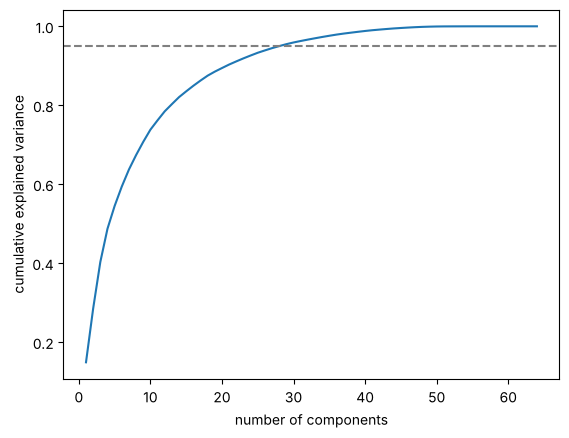

components for 95%: 29


In [24]:
from sklearn.datasets import load_digits

X_dig = load_digits().data
pca_full = PCA().fit(X_dig)
cum = np.cumsum(pca_full.explained_variance_ratio_)

plt.plot(range(1, len(cum) + 1), cum)
plt.axhline(0.95, ls='--', c='grey')
plt.xlabel('number of components'); plt.ylabel('cumulative explained variance')
plt.show()

print("components for 95%:", np.argmax(cum >= 0.95) + 1)

Passing a float to `n_components` does this automatically:

In [25]:
PCA(n_components=0.95).fit(X_dig).n_components_

np.int64(29)

PCA is sensitive to scale (it's all about variance), so standardise first when features have different units.

---

## 4. Pipelines

Preprocessing steps have to be applied in the same order, with the same fitted parameters, to the training
data, the validation data, the test data and any new data later. Doing that by hand is where bugs come from.
A `Pipeline` bundles the steps into a single estimator:

* every step except the last must be a transformer (`fit` + `transform`)
* the last step can be anything (usually a model)
* `pipe.fit(X, y)` fits each step in turn, `pipe.predict(X)` transforms and then predicts

### Creating one

In [26]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer

pipe = Pipeline(steps=[
    ('imputer', SimpleImputer()),
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('regressor', LinearRegression()),
])
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account

`make_pipeline` does the same without having to name the steps (names are the lowercase class names):

In [27]:
make_pipeline(SimpleImputer(), StandardScaler(), LinearRegression()).steps

[('simpleimputer', SimpleImputer()),
 ('standardscaler', StandardScaler()),
 ('linearregression', LinearRegression())]

### Accessing steps and parameters

In [28]:
len(pipe.steps), [name for name, _ in pipe.steps]

(4, ['imputer', 'scaler', 'pca', 'regressor'])

In [29]:
# four ways to get the PCA step
pipe.named_steps['pca'], pipe.named_steps.pca, pipe['pca'], pipe[2]

(PCA(), PCA(), PCA(), PCA())

In [30]:
pipe[:2]     # slicing gives a sub-pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for 

Parameters of a step are `<step name>__<parameter>` (two underscores):

In [31]:
pipe.set_params(pca__n_components=5)
pipe.get_params()['pca__n_components']

5

### Using it

On the diabetes data with some values knocked out so the imputer has something to do:

In [32]:
X_holes = X_diab.copy()
mask = np.random.RandomState(0).rand(*X_holes.shape) < 0.05
X_holes[mask] = np.nan
print("missing values:", X_holes.isna().sum().sum())

X_train, X_test, y_train, y_test = train_test_split(X_holes, y_diab, random_state=0)

pipe.fit(X_train, y_train)
print(f"test R2: {pipe.score(X_test, y_test):.3f}")

missing values: 227
test R2: 0.364


The imputer means, scaler stats and PCA axes were all learned from `X_train` only, and reused on `X_test`.
(The R2 is lowish partly because PCA is squeezing 10 features into 5. Linear regression on the full diabetes
data only gets about 0.48 cross-validated anyway.)

### Grid search over a pipeline

Because of the `step__param` naming, `GridSearchCV` can tune any step. A step can even be swapped out
entirely by using its name as the key.

Breast cancer classification, comparing two classifiers, a few values of `C`, and with/without PCA:

In [33]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

X_bc, y_bc = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X_bc, y_bc, random_state=0, stratify=y_bc)

clf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('reduce', 'passthrough'),
    ('clf', LogisticRegression(max_iter=1000)),
])

param_grid = {
    'reduce': ['passthrough', PCA(10)],
    'clf': [LogisticRegression(max_iter=1000), SVC()],
    'clf__C': [0.1, 1, 10, 100],
}

search = GridSearchCV(clf_pipe, param_grid, cv=5).fit(X_train, y_train)
print("best params:", search.best_params_)
print(f"best CV accuracy: {search.best_score_:.3f}")
print(f"test accuracy:    {search.score(X_test, y_test):.3f}")

best params: {'clf': SVC(), 'clf__C': 1, 'reduce': 'passthrough'}
best CV accuracy: 0.986
test accuracy:    0.958


In [34]:
res = pd.DataFrame(search.cv_results_)
res['reduce'] = res['param_reduce'].astype(str)
res['clf'] = res['param_clf'].astype(str).str.split('(').str[0]
res.pivot_table(index=['clf', 'reduce'], columns='param_clf__C', values='mean_test_score').round(3)

param_clf__C                             0.1    1.0    10.0   100.0
clf                reduce                                          
LogisticRegression PCA(n_components=10)  0.981  0.981  0.974  0.967
                   passthrough           0.979  0.974  0.958  0.951
SVC                PCA(n_components=10)  0.953  0.979  0.977  0.967
                   passthrough           0.946  0.986  0.979  0.974

`C` is the inverse of regularisation strength: smaller `C` means stronger regularisation.

### Caching

During a grid search the early steps get refit with the same parameters over and over. `memory=` caches
fitted transformers to disk so they're reused.

In [35]:
from tempfile import mkdtemp
from shutil import rmtree

cache_dir = mkdtemp()
cached_pipe = Pipeline([('scaler', StandardScaler()), ('pca', PCA(10)), ('clf', SVC())],
                       memory=cache_dir)
cached_pipe.fit(X_train, y_train).score(X_test, y_test)

0.951048951048951

In [36]:
rmtree(cache_dir)     # clean up afterwards

### FeatureUnion

Where a `Pipeline` runs steps one after another, `FeatureUnion` runs transformers **in parallel** on the
same input and concatenates their outputs. For example: PCA components plus the best original features.

In [37]:
from sklearn.pipeline import FeatureUnion
from sklearn.feature_selection import f_classif

union = FeatureUnion([
    ('pca', PCA(n_components=3)),
    ('best', SelectKBest(f_classif, k=2)),
])
X_union = union.fit_transform(StandardScaler().fit_transform(X_bc), y_bc)
X_union.shape          # 3 PCA components + 2 selected features

(569, 5)

### Visualising a pipeline

In Jupyter/Colab a pipeline displays as an interactive diagram (click a box to see its parameters).
`set_config(display='diagram')` is the default in recent versions.

A full preprocessing + model setup for the abalone data: numeric columns are imputed and scaled, `Sex` is
one-hot encoded, then a regressor predicts `Rings`.

In [38]:
from sklearn import set_config
from sklearn.ensemble import RandomForestRegressor
set_config(display='diagram')

cols = ['Sex', 'Length', 'Diameter', 'Height', 'Whole weight',
        'Shucked weight', 'Viscera weight', 'Shell weight', 'Rings']
abalone = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data',
                      header=None, names=cols)
X_ab, y_ab = abalone.drop(columns='Rings'), abalone['Rings']
num_cols = X_ab.columns.drop('Sex').tolist()

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

preprocess = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['Sex']),
])

model = Pipeline([
    ('preprocess', preprocess),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=0)),
])
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If t

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X_ab, y_ab, random_state=0)
model.fit(X_train, y_train)
print(f"test R2: {model.score(X_test, y_test):.3f}")

test R2: 0.548


In [40]:
model[:-1].get_feature_names_out()     # columns after preprocessing

array(['num__Length', 'num__Diameter', 'num__Height', 'num__Whole weight',
       'num__Shucked weight', 'num__Viscera weight', 'num__Shell weight',
       'cat__Sex_F', 'cat__Sex_I', 'cat__Sex_M'], dtype=object)

The course version of this used `LabelBinarizer` inside a `ColumnTransformer`, which doesn't work:
`LabelBinarizer` is meant for targets and its `fit` doesn't accept `X` the way a transformer step needs to.
`OneHotEncoder` is the right tool for categorical feature columns.

## References

* [sklearn feature selection guide](https://scikit-learn.org/stable/modules/feature_selection.html)
* [sklearn PCA guide](https://scikit-learn.org/stable/modules/decomposition.html#pca)
* [Pipelines and composite estimators](https://scikit-learn.org/stable/modules/compose.html)